In [1]:
try:
  %matplotlib ipympl
except:
  pass


In [2]:
import os, sys, subprocess

REPO = "https://github.com/jongmoonha/Train_fault_simulation.git"
DIR  = "Train_fault_simulation"

try:
    import google.colab  # Colab 전용 모듈
    if not os.path.isdir(DIR):
        subprocess.run(["git","clone",REPO], check=True)
    print('We are in Google Colab environment.')
    os.chdir('/content/'+DIR)
    print('Current working directory:', os.getcwd())

except ImportError:
    print('We are in a local environment, not Google Colab.')
    pass

We are in a local environment, not Google Colab.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.stats import kurtosis

from utils.utils_processing import fft_simple, filtering, get_fault_frequency, fault_repeat_uncertainty, generate_unit_impulse_response, envelope_spectrum_band, real_cepstrum
from utils.utils_plot import plot_raw, plot_spectrum, five_harmonics, plot_cepstrum
from utils import kurtogram as kg

In [4]:
import mat73

%matplotlib widgetmal Signal (or Import the Signal)

# Configuration for the Generation

In [5]:
config = {
    'condition': 'I',      # 'I' | 'O' | 'B'
    'fs': 51200,
    'T' : 20,
    'segments': 50,
    'speed_rpm': 1350,     # shaft speed
    'Bd': 7.6, 'Nb': 8, 'd1': 20, 'd2': 47, 'a': 0,
    'beta_range': (4000, 8000),
    'fn_range': (12000, 12010),
    'fault_amp': 0.3,
    'A_normal': 0.2, # 0.1 for Inner, 0.2 for outer, 
    'nlevel' : 7,
    'nlevel_seg' : 4,
}

# Normal Signal Import

In [6]:
dir = './data_field/'
filename = 'Log'
# filename = 'Log107'

dir_file = dir + filename + '.mat'
data = mat73.loadmat(dir_file)

v_tot = data[filename]['rawdata']  # vibration signal
fs = 51200  # sampling frequency
t = np.arange(len(v_tot)) / fs  # time vector
N = len(v_tot)  # number of samples
T = t[-1]

# Signal Info
print('Signal Info:')
print(f'  Sampling Frequency: {fs} Hz')
print(f'  Signal Length: {N} samples ({T:.3f} sec)')

Signal Info:
  Sampling Frequency: 51200 Hz
  Signal Length: 1536001 samples (30.000 sec)


Text(0, 0.5, 'Amplitude')

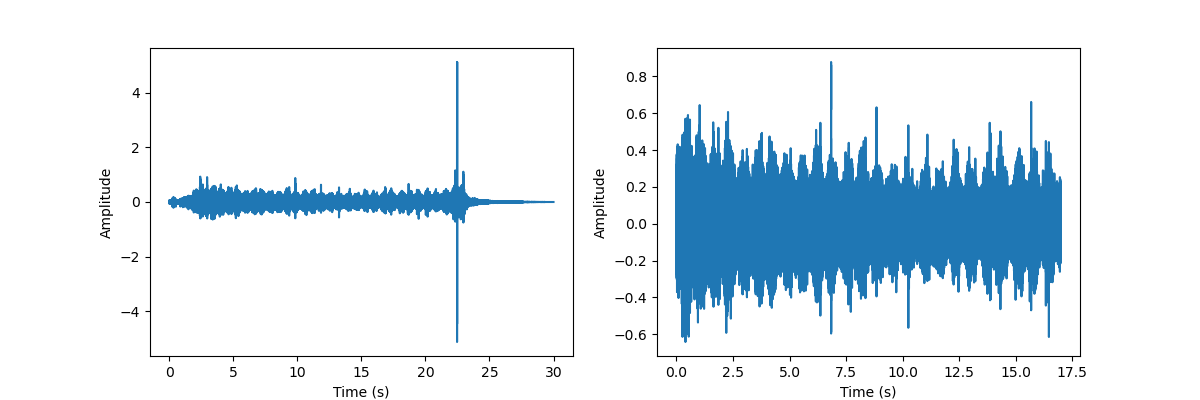

In [ ]:
ch = 0
x_normal = v_tot[:, ch]
t = t = np.arange(len(x_normal)) / fs  # time vector
N = len(x_normal)

plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
plt.plot(t, x_normal)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
x_normal = x_normal[(t>3) & (t<20)]
t = t = np.arange(len(x_normal)) / fs  # time vector
N = len(x_normal)

plt.subplot(1,2,2)
plt.plot(t, x_normal)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')


# Fault Signal Generation

### Fault Feature

### Fault Signal

In [28]:
rng = np.random.default_rng(0)

# Fault Characteristic Frequency
fault_freq, FTF, FCF, unit = get_fault_frequency(config)
fr = config['speed_rpm']/60
print(f'Rotational frequency: {fr:.1f} Hz')
print(f'freq_w_fault_featurey: {fault_freq:.1f} Hz')

# Unit impulse response
unit_fault_feature, Beta, Fn = generate_unit_impulse_response(t, config['beta_range'], config['fn_range'], rng)

# Synthesized Faulty Signal
x_fault_feature = fault_repeat_uncertainty(unit_fault_feature, FCF, fr, t, fs, FTF, config['condition']) * config['fault_amp']
x_fault_signal = x_normal + x_fault_feature

Rotational frequency: 22.5 Hz
freq_w_fault_featurey: 110.4 Hz


### Raw, Spectrum, Env

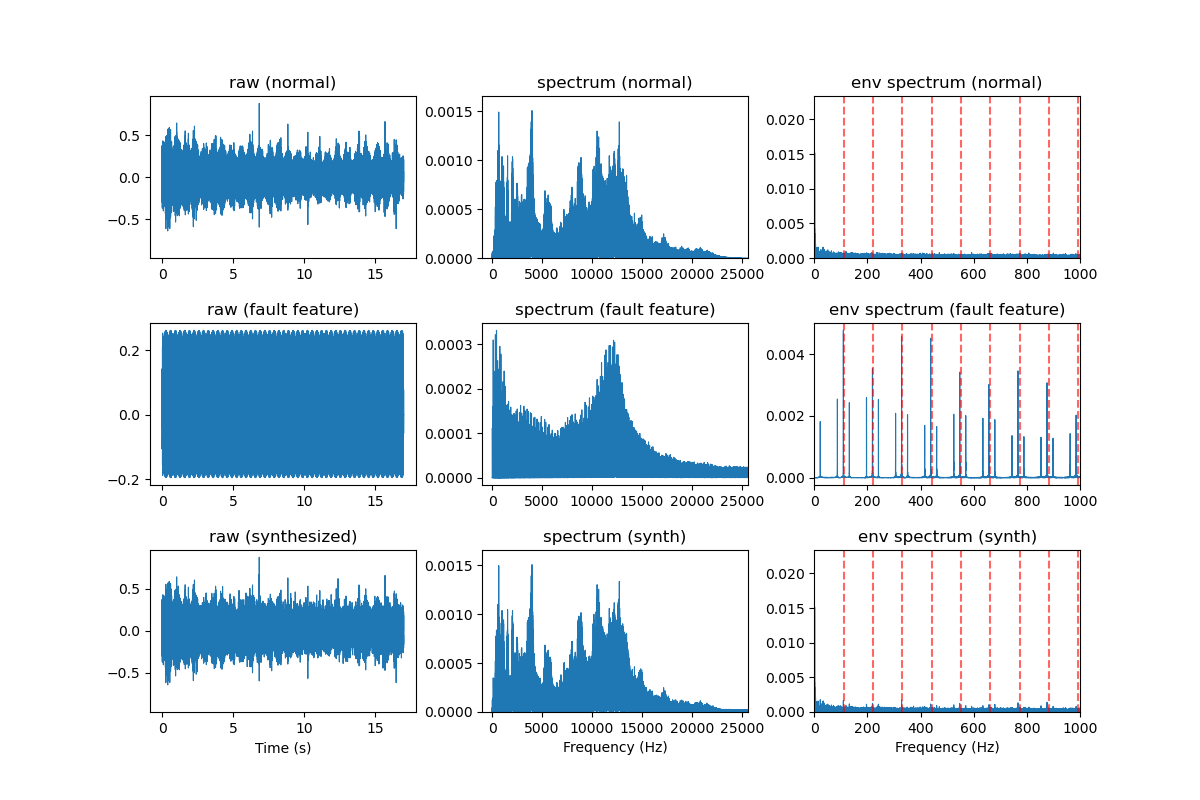

In [29]:
# 4-1~4-12) Plots
fig, axs = plt.subplots(3, 3, figsize=(12, 8))
axs = axs.ravel()

ymax = np.max(x_fault_signal)
plot_raw(axs[0], t, x_normal, 'raw (normal)'); axs[0].set_ylim([-1.1*ymax, 1.1*ymax])
plot_raw(axs[3], t, x_fault_feature, 'raw (fault feature)')
plot_raw(axs[6], t, x_fault_signal, 'raw (synthesized)'); axs[6].set_ylim([-1.1*ymax, 1.1*ymax])

xlim = [-1000, fs/2]
ymax = 1.1*np.max(fft_simple(x_fault_signal-np.mean(x_fault_signal), fs)[1])

plot_spectrum(axs[1], x_normal, fs, 'spectrum (normal)', xlim=xlim, ylim=ymax)
plot_spectrum(axs[4], x_fault_feature, fs, 'spectrum (fault feature)', xlim=xlim)
plot_spectrum(axs[7], x_fault_signal, fs, 'spectrum (synth)', xlim=xlim, ylim=ymax)

xlim = [0, 1000]
harmonic_lines = [h for h in five_harmonics(fault_freq, n=10) if h <= 1000]
env = np.abs(hilbert(x_fault_signal))
ymax = 1.1*np.max(fft_simple(env-np.mean(env), fs)[1])

plot_spectrum(axs[2], np.abs(hilbert(x_normal)), fs, 'env spectrum (normal)', harmonic_lines, xlim=xlim, ylim=ymax)
plot_spectrum(axs[5], np.abs(hilbert(x_fault_feature)), fs, 'env spectrum (fault feature)', harmonic_lines, xlim=xlim)
plot_spectrum(axs[8], np.abs(hilbert(x_fault_signal)), fs, 'env spectrum (synth)', harmonic_lines, xlim=xlim, ylim=ymax)

axs[6].set_xlabel('Time (s)')
axs[7].set_xlabel('Frequency (Hz)')
axs[8].set_xlabel('Frequency (Hz)')
# add margins between subplots (axes)
plt.subplots_adjust(hspace=0.4, wspace=0.25)
plt.show()


# Kurtogram and Envelope Analysis w/ Band-pass Filtering

In [30]:
nlevel = config['nlevel']
Kwav_norm, Level_w_norm, freq_w_norm, c_norm, maxK_norm, bw_norm, lvl_norm, Wn_norm = kg.fast_kurtogram(x_normal, fs, nlevel=nlevel)
Kwav_fault_feature, Level_w_fault_feature, freq_w_fault_feature, c_fault_feature, maxK_fault_feature, bw_fault_feature, lvl_fault_feature, Wn_fault_feature = kg.fast_kurtogram(x_fault_feature, fs, nlevel=nlevel)
Kwav_fault_signal, Level_w_fault_signal, freq_w_fault_signal, c_fault_signal, maxK_fault_signal, bw_fault_signal, lvl_fault_signal, Wn_fault_signal = kg.fast_kurtogram(x_fault_signal, fs, nlevel=nlevel)
f_e_n, A_e_n, env_n, xf_n = envelope_spectrum_band(x_normal, fs, Wn_norm)
f_e_f, A_e_f, env_f, xf_f = envelope_spectrum_band(x_fault_feature, fs, Wn_fault_feature)
f_e_s, A_e_s, env_s, xf_s = envelope_spectrum_band(x_fault_signal, fs, Wn_fault_signal)

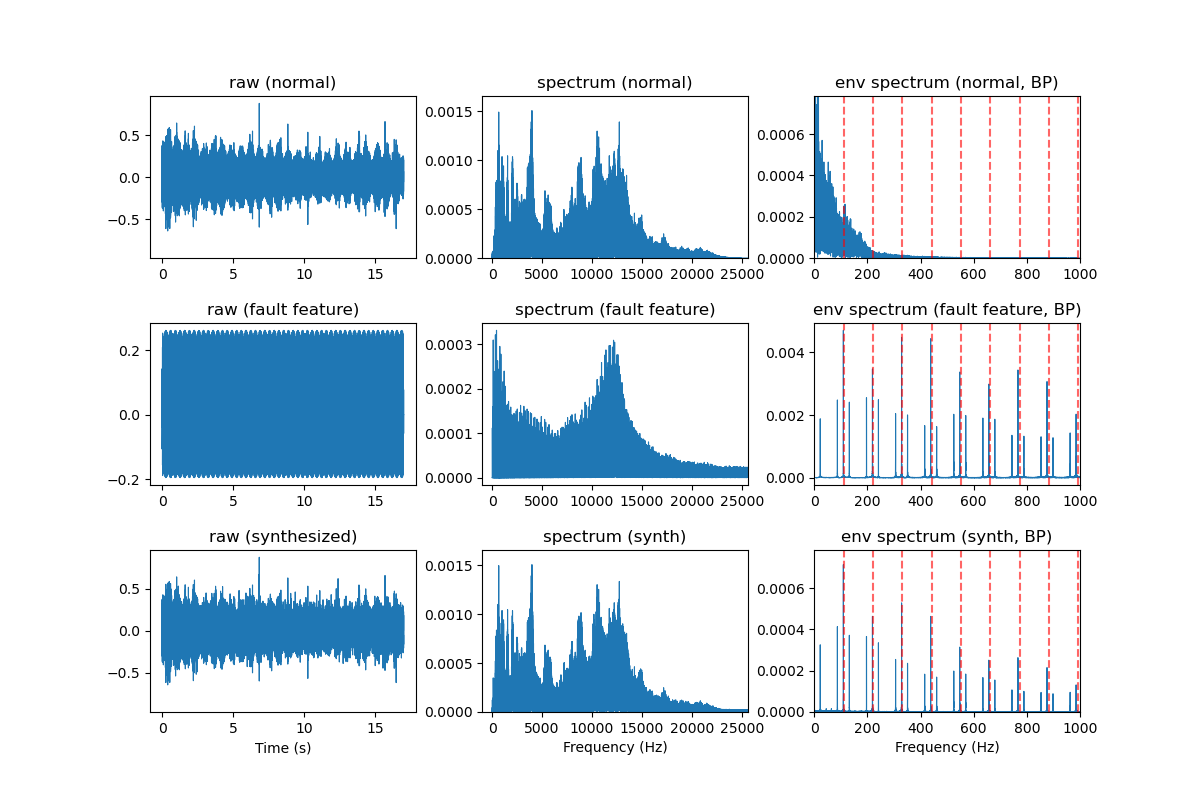

In [31]:
# 4-1~4-12) Plots
fig, axs = plt.subplots(3, 3, figsize=(12, 8))
axs = axs.ravel()

ymax = np.max(x_fault_signal)
plot_raw(axs[0], t, x_normal, 'raw (normal)'); axs[0].set_ylim([-1.1*ymax, 1.1*ymax])
plot_raw(axs[3], t, x_fault_feature, 'raw (fault feature)')
plot_raw(axs[6], t, x_fault_signal, 'raw (synthesized)'); axs[6].set_ylim([-1.1*ymax, 1.1*ymax])

xlim = [-1000, fs/2]
ymax = 1.1*np.max(fft_simple(x_fault_signal-np.mean(x_fault_signal), fs)[1])

plot_spectrum(axs[1], x_normal, fs, 'spectrum (normal)', xlim=xlim, ylim=ymax)
plot_spectrum(axs[4], x_fault_feature, fs, 'spectrum (fault feature)', xlim=xlim)
plot_spectrum(axs[7], x_fault_signal, fs, 'spectrum (synth)', xlim=xlim, ylim=ymax)

xlim = [0, 1000]
harmonic_lines = [h for h in five_harmonics(fault_freq, n=10) if h <= 1000]
ymax = 1.1*np.max(fft_simple(env_s-np.mean(env_s), fs)[1])

plot_spectrum(axs[2], env_n, fs, 'env spectrum (normal, BP)', harmonic_lines, xlim=xlim, ylim=ymax)
plot_spectrum(axs[5], env_f, fs, 'env spectrum (fault feature, BP)', harmonic_lines, xlim=xlim)
plot_spectrum(axs[8], env_s, fs, 'env spectrum (synth, BP)', harmonic_lines, xlim=xlim, ylim=ymax)

axs[6].set_xlabel('Time (s)')
axs[7].set_xlabel('Frequency (Hz)')
axs[8].set_xlabel('Frequency (Hz)')


# add margins between subplots (axes)
plt.subplots_adjust(hspace=0.4, wspace=0.25)
plt.show()


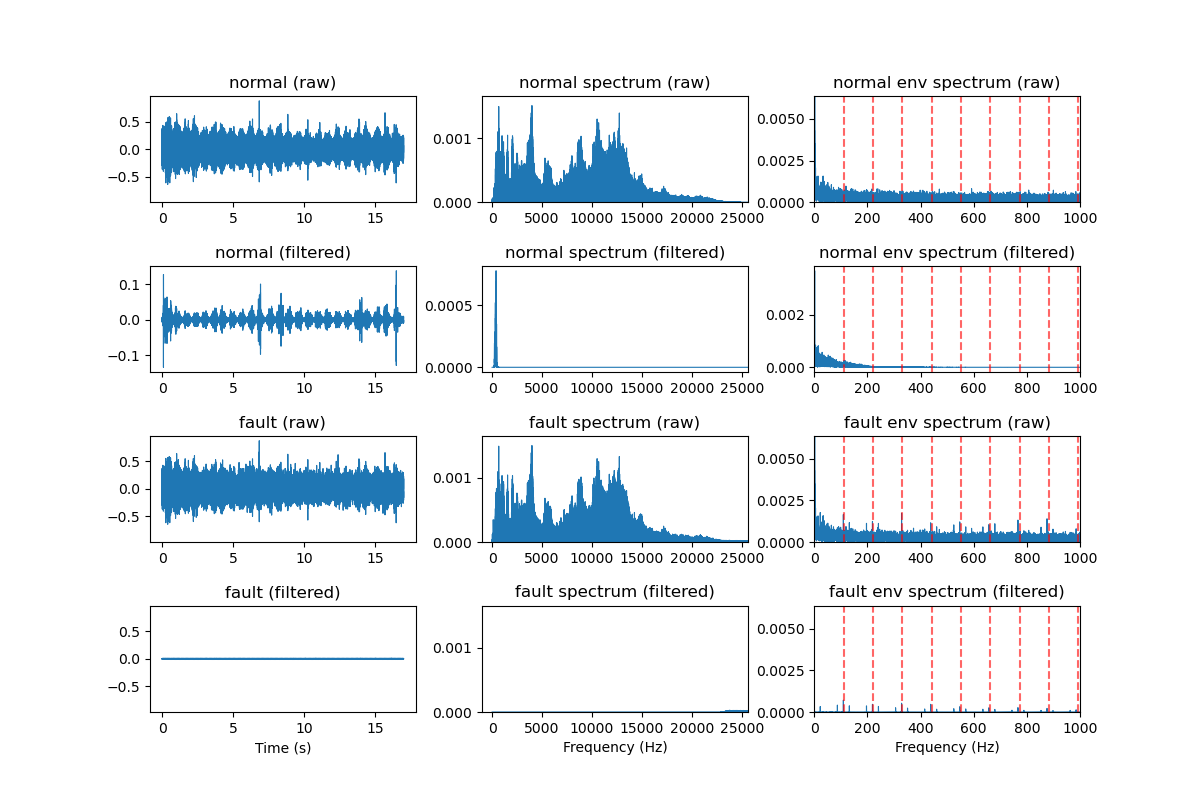

In [32]:
fig, axs = plt.subplots(4, 3, figsize=(12, 8))
axs = axs.ravel()

ymax = np.max(x_fault_signal)
plot_raw(axs[0], t, x_normal, 'normal (raw)'); axs[0].set_ylim([-1.1*ymax, 1.1*ymax])
plot_raw(axs[3], t, xf_n, 'normal (filtered)')
plot_raw(axs[6], t, x_fault_signal, 'fault (raw)'); axs[6].set_ylim([-1.1*ymax, 1.1*ymax])
plot_raw(axs[9], t, xf_s, 'fault (filtered)'); axs[9].set_ylim([-1.1*ymax, 1.1*ymax])

xlim = [-1000, fs/2]
ymax = 1.1*np.max(fft_simple(x_fault_signal-np.mean(x_fault_signal), fs)[1])

plot_spectrum(axs[1], x_normal, fs, 'normal spectrum (raw)', xlim=xlim, ylim=ymax)
plot_spectrum(axs[4], xf_n, fs, 'normal spectrum (filtered)', xlim=xlim)
plot_spectrum(axs[7], x_fault_signal, fs, 'fault spectrum (raw)', xlim=xlim, ylim=ymax)
plot_spectrum(axs[10], xf_s, fs, 'fault spectrum (filtered)', xlim=xlim, ylim=ymax)

xlim = [0, 1000]
harmonic_lines = [h for h in five_harmonics(fault_freq, n=10) if h <= 1000]
x_fault_env = np.abs(hilbert(x_fault_signal))
ymax = 0.3*np.max(fft_simple(x_fault_env-np.mean(x_fault_env), fs)[1])

plot_spectrum(axs[2], np.abs(hilbert(x_normal)), fs, 'normal env spectrum (raw)', harmonic_lines, xlim=xlim, ylim=ymax)
plot_spectrum(axs[5], np.abs(hilbert(xf_n)), fs, 'normal env spectrum (filtered)', harmonic_lines, xlim=xlim)
plot_spectrum(axs[8], np.abs(hilbert(x_fault_signal)), fs, 'fault env spectrum (raw)', harmonic_lines, xlim=xlim, ylim=ymax)
plot_spectrum(axs[11], np.abs(hilbert(xf_s)), fs, 'fault env spectrum (filtered)', harmonic_lines, xlim=xlim, ylim=ymax)


axs[9].set_xlabel('Time (s)')
axs[10].set_xlabel('Frequency (Hz)')
axs[11].set_xlabel('Frequency (Hz)')

# add margins between subplots (axes)
plt.subplots_adjust(hspace=0.6, wspace=0.25)
plt.show()


# Feature Visualization

### Kurtogram

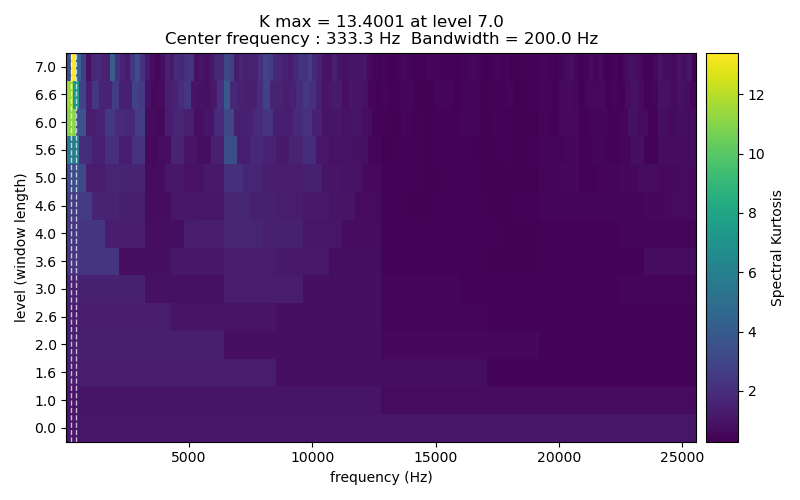

d:\Main\03_프로젝트\04_과제 (진행)\2024-2025 Korail\04_과제 진행 (연구)\Python_code_simulation\utils\kurtogram.py:113: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 5))


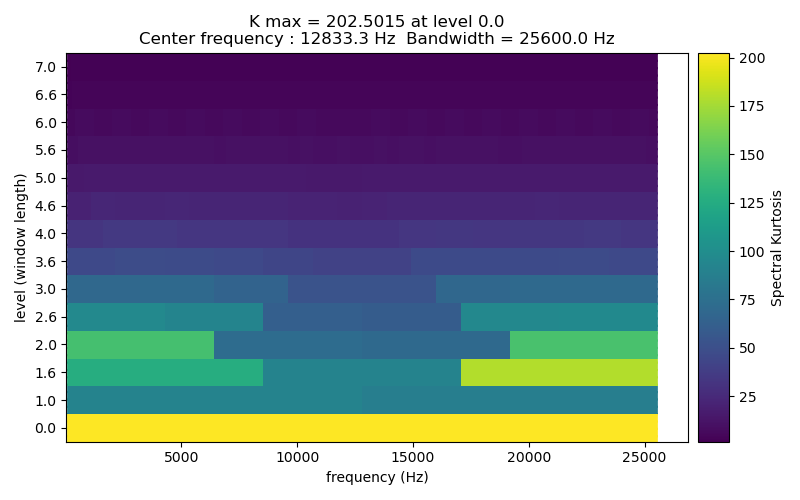

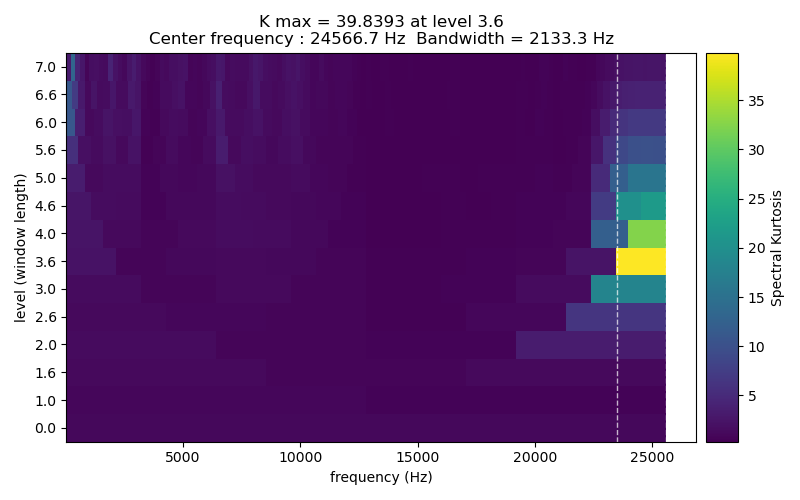

In [33]:
# Show kurtograms (optional visual)
kg.plot_kurtogram(Kwav_norm, Level_w_norm, maxK_norm, bw_norm, lvl_norm, fs, Wn_norm)
kg.plot_kurtogram(Kwav_fault_feature, Level_w_fault_feature, maxK_fault_feature, bw_fault_feature, lvl_fault_feature, fs, Wn_fault_feature)
kg.plot_kurtogram(Kwav_fault_signal, Level_w_fault_signal, maxK_fault_signal, bw_fault_signal, lvl_fault_signal, fs, Wn_fault_signal)

### Envelope Spectrum

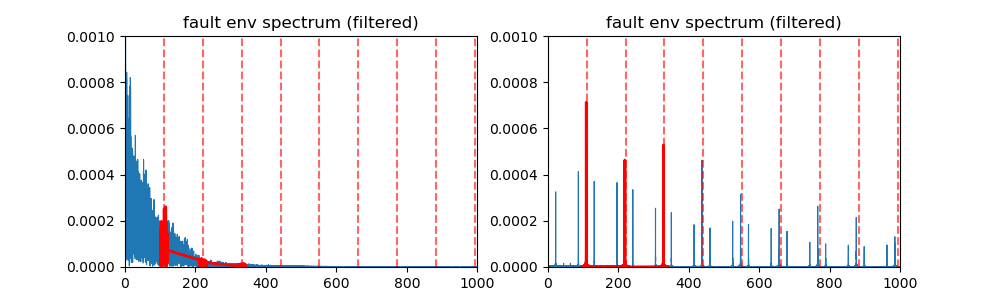

In [59]:
f, A = fft_simple(xf_n-np.mean(xf_n), fs)

f_range = 10
harmonics = np.arange(1, 4)
idx_range = [
    np.where((f >= k*fault_freq - f_range) & (f <= k*fault_freq + f_range))[0]
    for k in harmonics
]
idx_range = np.concatenate(idx_range)
    
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

env = np.abs(hilbert(xf_n))
f, A = fft_simple(env-np.mean(env), fs)
plot_spectrum(ax[0], np.abs(hilbert(xf_n)), fs, 'fault env spectrum (filtered)', harmonic_lines, xlim=xlim, ylim=0.001)
ax[0].plot(f[idx_range], A[idx_range], color='r', linewidth=2)

env = np.abs(hilbert(xf_s))
f, A = fft_simple(env-np.mean(env), fs)
plot_spectrum(ax[1], np.abs(hilbert(xf_s)), fs, 'fault env spectrum (filtered)', harmonic_lines, xlim=xlim, ylim=0.001)
ax[1].plot(f[idx_range], A[idx_range], color='r', linewidth=2)

### Cepstrum

In [14]:
1/fault_freq

np.float64(0.009056501757231685)

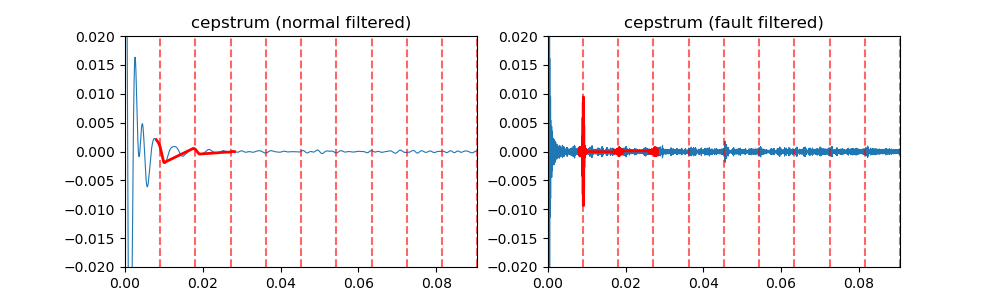

In [76]:
# cep_n = real_cepstrum(x_normal-np.mean(x_normal))
# cep_f = real_cepstrum(x_fault_signal-np.mean(x_fault_signal))
# cep_x = np.arange(len(cep_n)) / fs

cep_n = real_cepstrum(xf_n-np.mean(xf_n))
cep_f = real_cepstrum(xf_s-np.mean(xf_s))
cep_x = np.arange(len(cep_n)) / fs

vlines = [h for h in five_harmonics(1/fault_freq, n=10) if h <= 1000]

t_range = 0.001
harmonics = np.arange(1, 4)
idx_range = [
    np.where((cep_x >= k/(fault_freq) - t_range) & (cep_x <= k/(fault_freq) + t_range))[0]
    for k in harmonics
]
idx_range = np.concatenate(idx_range)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

plot_cepstrum(ax[0], cep_x, cep_n, title='cepstrum (normal filtered)', vlines=vlines, xlim=[0, 1/fault_freq * 10], ylim=[-0.02, 0.02])
ax[0].plot(cep_x[idx_range], cep_n[idx_range], color='r', linewidth=2)

plot_cepstrum(ax[1], cep_x, cep_f, title='cepstrum (fault filtered)', vlines=vlines, xlim=[0, 1/fault_freq * 10], ylim=[-0.02, 0.02])
ax[1].plot(cep_x[idx_range], cep_f[idx_range], color='r', linewidth=2)

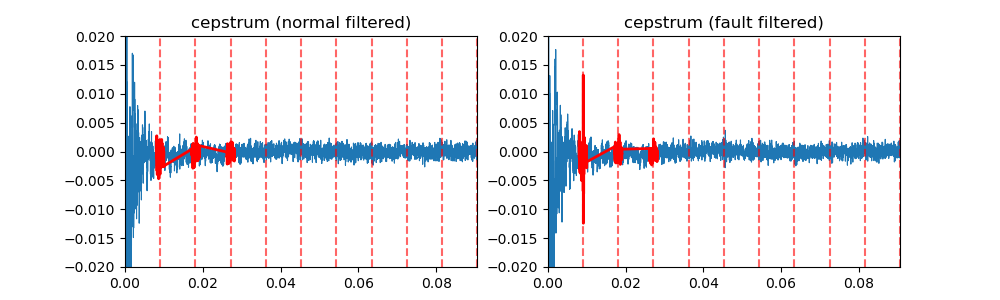

In [77]:
cep_n = real_cepstrum(x_normal-np.mean(x_normal))
cep_f = real_cepstrum(x_fault_signal-np.mean(x_fault_signal))
cep_x = np.arange(len(cep_n)) / fs

# cep_n = real_cepstrum(xf_n-np.mean(xf_n))
# cep_f = real_cepstrum(xf_s-np.mean(xf_s))
# cep_x = np.arange(len(cep_n)) / fs

vlines = [h for h in five_harmonics(1/fault_freq, n=10) if h <= 1000]

t_range = 0.001
harmonics = np.arange(1, 4)
idx_range = [
    np.where((cep_x >= k/(fault_freq) - t_range) & (cep_x <= k/(fault_freq) + t_range))[0]
    for k in harmonics
]
idx_range = np.concatenate(idx_range)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

plot_cepstrum(ax[0], cep_x, cep_n, title='cepstrum (normal filtered)', vlines=vlines, xlim=[0, 1/fault_freq * 10], ylim=[-0.02, 0.02])
ax[0].plot(cep_x[idx_range], cep_n[idx_range], color='r', linewidth=2)

plot_cepstrum(ax[1], cep_x, cep_f, title='cepstrum (fault filtered)', vlines=vlines, xlim=[0, 1/fault_freq * 10], ylim=[-0.02, 0.02])
ax[1].plot(cep_x[idx_range], cep_f[idx_range], color='r', linewidth=2)

In [16]:
# _, _, _, _, _, _, _, Wn = kg.fast_kurtogram(seg_n[0], fs, nlevel=nlevel_seg)
# _, _, _, seg_n0 = envelope_spectrum_band(seg_n[0], fs, Wn)
# cep_n = real_cepstrum(seg_n0-np.mean(seg_n0))

# _, _, _, _, _, _, _, Wn = kg.fast_kurtogram(seg_f[0], fs, nlevel=nlevel_seg)
# _, _, _, seg_f0 = envelope_spectrum_band(seg_f[0], fs, Wn)
# cep_f = real_cepstrum(seg_f0-np.mean(seg_f0))

# cep_x = np.arange(len(seg_n[0])) / fs

# vlines = [h for h in five_harmonics(1/fault_freq, n=10) if h <= 1000]

# t_range = 0.001
    
# harmonics = np.arange(1, 2)
# idx_range = [
#     np.where((t >= k/(fault_freq) - t_range) & (t <= k/(fault_freq) + t_range))[0]
#     for k in harmonics
# ]

# idx_range = np.concatenate(idx_range)

# print(np.mean(np.abs(cep_n[idx_range])))
# print(np.mean(np.abs(cep_f[idx_range])))

# print(np.max(cep_n[idx_range])/np.sqrt(np.mean(cep_n[idx_range]**2)))
# print(np.max(cep_f[idx_range])/np.sqrt(np.mean(cep_f[idx_range]**2)))

# fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# env = np.abs(hilbert(seg_n[0]))
# plot_cepstrum(ax[0], cep_x, cep_n, title='cepstrum (normal filtered)', vlines=vlines, xlim=[0, 1/fault_freq * 10], ylim=[-0.02, 0.02])
# ax[0].plot(cep_x[idx_range], cep_n[idx_range], color='r', linewidth=2)

# env = np.abs(hilbert(seg_f[0]))
# plot_cepstrum(ax[1], cep_x, cep_f, title='cepstrum (fault filtered)', vlines=vlines, xlim=[0, 1/fault_freq * 10], ylim=[-0.02, 0.02])
# ax[1].plot(cep_x[idx_range], cep_f[idx_range], color='r', linewidth=2)

# Feature Calculation from each Segment

In [37]:
S = config['segments']
L = N//S

def segments(x):
    return x[:S*L].reshape(S, L)

seg_n = segments(x_normal)
seg_f = segments(x_fault_signal)

print(f'The number of segments: {S}, segment length: {L} samples ({L/fs:.3f} sec)')

The number of segments: 50, segment length: 17407 samples (0.340 sec)


In [39]:
seg_f.shape

(50, 17407)

In [43]:
# Segment Visualization

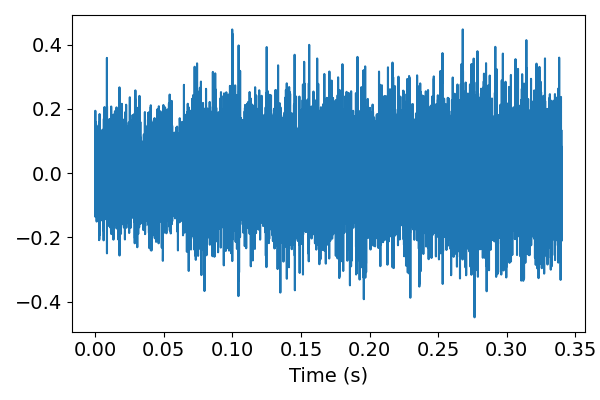

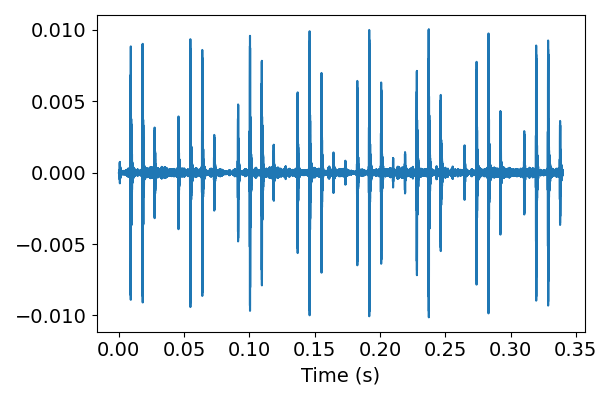

In [74]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t[:L], seg_f[10])
ax.set_xlabel('Time (s)', fontsize=14)
# adjust x, y grid font size
ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()

_, _, _, _, kurt_filtered, _, _, Wn = kg.fast_kurtogram(seg_f[10], fs, nlevel=config['nlevel_seg'])
f, A, env, x_filtered = envelope_spectrum_band(seg_f[10], fs, Wn)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t[:L], x_filtered)
ax.set_xlabel('Time (s)', fontsize=14)
# adjust x, y grid font size
ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()


In [18]:
import importlib
import utils.utils_processing as up
importlib.reload(up)

from utils.utils_processing import def_features


In [19]:
nlevel_seg = config['nlevel_seg']

feat_n = []
for v in seg_n:
    feat, feat_names = def_features(v, fs, fault_freq, nlevel_seg)
    feat_n.append(feat)
feat_n = np.array(feat_n)

feat_f = []
for v in seg_f:
    feat, feat_names = def_features(v, fs, fault_freq, nlevel_seg)
    feat_f.append(feat)
feat_f = np.array(feat_f)

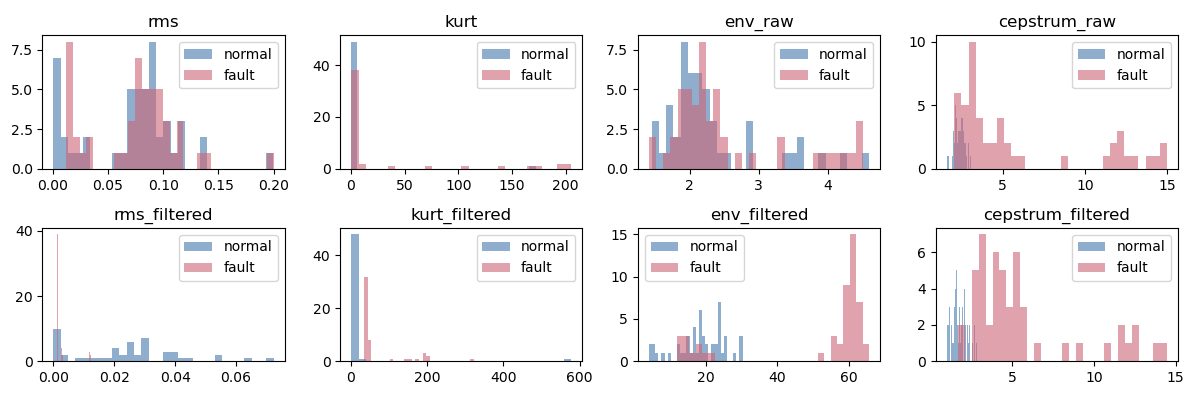

In [20]:
# Feature comparison: plot up to 7 feature histograms (normal vs synth) in a 4x2 grid
# Assumes feat_n and feat_f are (S, F) numpy arrays and feat_names is available
S, F = feat_n.shape

fig, axs = plt.subplots(2, 4, figsize=(12, 4))
axs = axs.ravel()

for i in range(8):
    axs[i].hist(feat_n[:, i], bins=30, color='#4477AA', alpha=0.6, label='normal')
    axs[i].hist(feat_f[:, i], bins=30, color='#CC6677', alpha=0.6, label='fault')
    title = feat_names[i] if 'feat_names' in globals() and i < len(feat_names) else f'feature {i+1}'
    axs[i].set_title(title)
    axs[i].legend()

plt.tight_layout()
plt.show()


Text(0, 0.5, 'env_filtered')

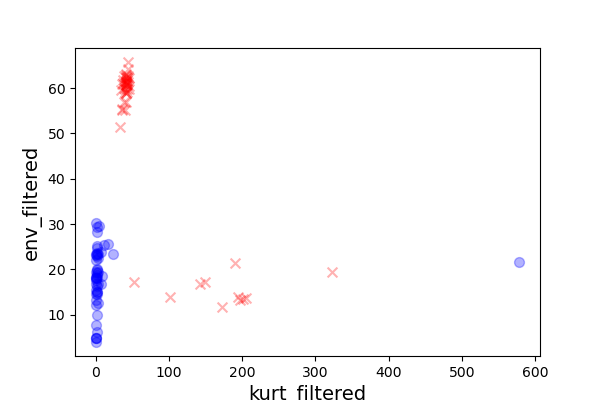

In [79]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

n1, n2 = 5, 6
ax.scatter(feat_n[:, n1], feat_n[:, n2], c='blue', marker='o', s=50, label='Normal', alpha=0.3)
ax.scatter(feat_f[:, n1], feat_f[:, n2], c='red', marker='x', s=50, label='Fault', alpha=0.3)
ax.set_xlabel(feat_names[n1], fontsize=14)
ax.set_ylabel(feat_names[n2], fontsize=14)

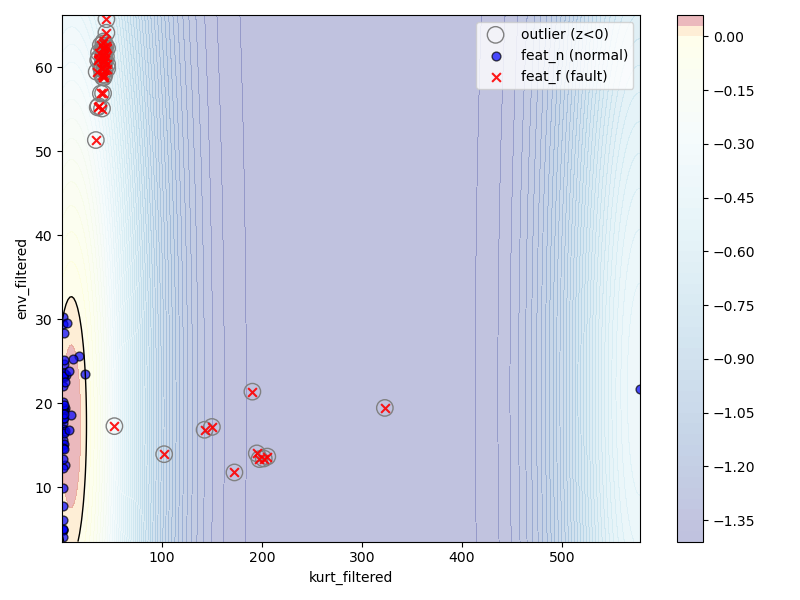

In [82]:
# One-Class SVM (1-class SVM) anomaly detection using feat_n; visualize on features 5 and 6
from sklearn.svm import OneClassSVM
from matplotlib.colors import TwoSlopeNorm

# feature indices to visualize (0-based). If you expect 1-based, change accordingly.
n1, n2 = 5, 6

# Train One-Class SVM on all features (used for scoring)
oc_full = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
oc_full.fit(feat_n)

# Also train a 2D One-Class SVM on features (n1,n2) for plotting a 2D decision boundary
X2d = feat_n[:, [n1, n2]]
oc_2d = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
oc_2d.fit(X2d)

# Create grid for decision boundary
xx, yy = np.meshgrid(
    np.linspace(np.min(np.vstack([X2d[:,0], feat_f[:, n1]])) - 0.5, np.max(np.vstack([X2d[:,0], feat_f[:, n1]])) + 0.5, 300),
    np.linspace(np.min(np.vstack([X2d[:,1], feat_f[:, n2]])) - 0.5, np.max(np.vstack([X2d[:,1], feat_f[:, n2]])) + 0.5, 300)
)
Z = oc_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
norm = TwoSlopeNorm(vmin=Z.min(), vcenter=0.0, vmax=Z.max())

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# decision function shading (optional subtle background)
cf = ax.contourf(xx, yy, Z, levels=50, cmap='RdYlBu_r',norm=norm, alpha=0.3)
cbar = fig.colorbar(cf, ax=ax)
# cbar.set_clim(-1, 1)   # colorbar 범위 조정
# cf.set_clim(-1, 1)     # 실제 contour shading도 함께 변경해야 일관됨

# decision boundary
ax.contour(xx, yy, Z, levels=[0], colors='k', linewidths=1)

# Mark points flagged as outliers by full model on top
pred_full = oc_full.predict(feat_f)
# pred_full = oc_2d.predict(feat_f[:, [n1, n2]])
out_idx = np.where(pred_full == -1)[0]
if out_idx.size > 0:
    ax.scatter(feat_f[out_idx, n1], feat_f[out_idx, n2], facecolors='none', edgecolors='gray', s=140, linewidths=1, label='outlier (z<0)')
    
# Plot feat_n and feat_f on same axes
ax.scatter(feat_n[:, n1], feat_n[:, n2], c='blue', marker='o', s=40, edgecolor='k', alpha=0.7, label='feat_n (normal)')
ax.scatter(feat_f[:, n1], feat_f[:, n2], c='red', marker='x', s=40, alpha=0.9, label='feat_f (fault)')

# ax.set_title(f'feat_n (blue o) and feat_f (red x) with OC-SVM boundary (features {n1},{n2})')
ax.set_xlabel(feat_names[n1])
ax.set_ylabel(feat_names[n2])
ax.legend(loc='best')
plt.tight_layout()
plt.show()
